# 16 · Vecinas cercanas: resultados frente al V4

Protocolo: `docs/protocolo_vecinas_cercanas_v1.md` (`v4k_multianual_33_p95cal2023_v1`).
Idea del tesista: que cada detector use sólo las estaciones **geográficamente cercanas**,
para no recibir ruido de estaciones lejanas o de otro tipo de zona.

| Familia | Qué estaciones ve | Contexto |
|---|---|---|
| **V4** (referencia) | las 32 | t−24 … t−1 |
| **knn** | las k más cercanas, con k ∈ {4, 8, 16, 32} elegido con 2022 por estación | t−24 … t−1 |

Si para una estación gana k = 32, su detector **es** el V4 (se copia, no se reentrena).
Este libro **no entrena ni calcula**: lee lo que produce el script.

## Cómo ejecutar (desde la raíz del repo)

```bash
nohup .venv/bin/python experiments/vecinas/ejecutar.py > /dev/null 2>&1 &
tail -f results/vecinas_cercanas_v1/ejecucion.log
```

Reanudable: si se interrumpe, se relanza igual. Etapas: entrenar → verificar → evaluar →
simultáneo.

In [1]:
import sys, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RAIZ = Path('..').resolve()
sys.path.insert(0, str(RAIZ))
warnings.filterwarnings('ignore')
from src.detect import multianual as m
from src.detect import vecinas as vc

K = RAIZ / 'results/vecinas_cercanas_v1'
V4 = RAIZ / 'results/lstm_v4_multianual_v1'
SIM_V4 = RAIZ / 'results/contemporaneo_v1/simultaneo/metricas_simultaneo_agregadas.csv'
IMG = RAIZ / 'docs/img/vecinas_cercanas_v1'
IMG.mkdir(parents=True, exist_ok=True)
FAM = {'v4': V4, 'knn': K}
COLOR = {'v4': '#52514e', 'knn': '#1baf7a'}
ETIQ = {'v4': 'V4 (32 vecinas)', 'knn': 'k vecinas cercanas'}
pd.set_option('display.width', 220)
plt.rcParams.update({'axes.grid': True, 'grid.color': '#e6e5e0', 'axes.spines.top': False,
                     'axes.spines.right': False, 'lines.linewidth': 2, 'legend.frameon': False,
                     'axes.titleweight': 'bold', 'axes.titlesize': 11})
cob = pd.read_csv(V4 / 'cobertura_etapas.csv')
CLASES = cob.drop_duplicates('objetivo').set_index('objetivo')['clasificacion']
geo = pd.read_csv(RAIZ / 'results/inventario_multianual/estaciones_geografia.csv', index_col=0)
DIST = vc.distancias(geo)
def leer(fam, archivo):
    f = FAM[fam] / archivo
    return pd.read_csv(f) if f.exists() else None

## 1. Estado de la ejecución

In [2]:
log = K / 'ejecucion.log'
print(''.join(log.read_text(encoding='utf-8').splitlines(keepends=True)[-8:]) if log.exists()
      else 'El script todavía no se ha ejecutado.')
n = len(list((K / 'estaciones').glob('*/configuracion.json'))) if (K / 'estaciones').exists() else 0
print(f'knn: {n}/31 estaciones listas')

2026-10-05 00:17:21  [simultaneo] 2026 bit 2: 249 horas (5 s)
2026-10-05 00:17:25  [simultaneo] 2026 bit 3: 249 horas (5 s)
2026-10-05 00:17:30  [simultaneo] 2026 bit 4: 249 horas (5 s)
2026-10-05 00:17:35  [simultaneo] 2026 bit 5: 249 horas (5 s)
2026-10-05 00:17:40  [simultaneo] 2026 bit 6: 249 horas (5 s)
2026-10-05 00:17:44  [simultaneo] 2026 bit 7: 249 horas (5 s)
2026-10-05 00:17:44  [simultaneo] listo
2026-10-05 00:17:44  === fin (43.3 min) ===

knn: 31/31 estaciones listas


## 2. ¿Cuántas vecinas eligió cada estación?

`val_loss` es el error en 2022 (validación) con cada k; gana el menor. Si gana 32, la
estación se queda con el V4. La columna `dist_max_km` es qué tan lejos está la vecina más
lejana usada.

In [3]:
filas = []
for obj in m.ESTACIONES:
    f = K / 'estaciones' / obj / 'seleccion_k.csv'
    if f.exists():
        s = pd.read_csv(f).assign(objetivo=obj)
        s['elegido'] = s.k == json.loads((K / 'estaciones' / obj / 'configuracion.json').read_text())['k']
        filas.append(s)
if filas:
    SEL = pd.concat(filas, ignore_index=True)
    elegidos = SEL[SEL.elegido].set_index('objetivo')
    print('k elegido:', elegidos.k.value_counts().sort_index().to_dict())
    piv = SEL.pivot(index='objetivo', columns='k', values='val_loss_min').round(1)
    piv['k*'] = elegidos.k; piv['clasificación'] = CLASES.reindex(piv.index)
    piv['altitud_m'] = geo.loc[piv.index, 'alt']
    piv['dist_media_a_otras_km'] = DIST.loc[piv.index].replace(0, np.nan).mean(axis=1).round(1)
    print(piv.sort_values('k*').to_string())
else:
    print('Sin resultados de selección todavía.')

k elegido: {4: 21, 8: 7, 16: 3}
k             4      8     16     32  k*           clasificación  altitud_m  dist_media_a_otras_km
objetivo                                                                                          
AJM       209.8  235.4  215.8  212.4   4  baja_representatividad     2548.0                   25.3
ATI        97.4   97.9  114.8  108.2   4               principal     2341.0                   27.2
CCA       131.6  156.9  152.4  154.0   4               principal     2294.0                   20.7
BJU       115.7  148.2  150.2  161.1   4               principal     2249.0                   18.4
FAR        78.6   87.7  102.5  110.6   4               principal     2230.0                   19.4
FAC        82.3   84.3   97.5  103.8   4               principal     2299.0                   22.3
CUT        92.1  105.0  114.8  117.5   4               principal     2263.0                   37.1
CUA       121.6  144.2  138.8  159.6   4               principal     2704.0  

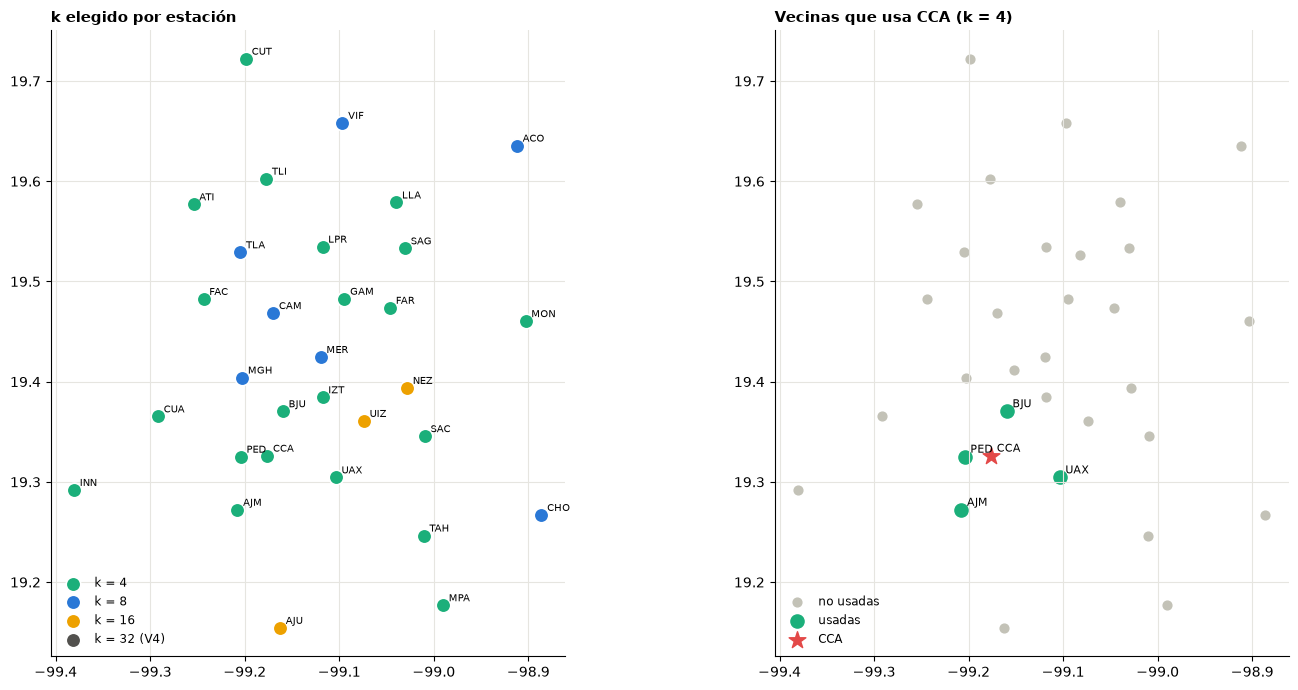

In [4]:
if filas:
    fig, axes = plt.subplots(1, 2, figsize=(15, 7))
    ax = axes[0]
    for kk, color in zip([4, 8, 16, 32], ['#1baf7a', '#2a78d6', '#eda100', '#52514e']):
        d = geo.loc[elegidos.index[elegidos.k == kk]]
        ax.scatter(d.longitud, d.latitud, s=110, color=color, edgecolor='white', lw=1.2, zorder=3,
                   label=f'k = {kk}' + (' (V4)' if kk == 32 else ''))
    for s, r in geo.loc[elegidos.index].iterrows():
        ax.text(r.longitud + 0.006, r.latitud + 0.004, s, fontsize=7.5)
    ax.set_aspect(1 / np.cos(np.radians(19.4))); ax.legend(fontsize=8.5, loc='lower left')
    ax.set_title('k elegido por estación', loc='left')

    ax = axes[1]
    obj = 'CCA'
    if obj in elegidos.index and elegidos.at[obj, 'k'] < 32:
        usadas = elegidos.at[obj, 'vecinas'].split()
        otras = [s for s in m.ESTACIONES if s not in usadas + [obj]]
        ax.scatter(geo.loc[otras].longitud, geo.loc[otras].latitud, s=40, color='#c3c2b7', label='no usadas')
        ax.scatter(geo.loc[usadas].longitud, geo.loc[usadas].latitud, s=90, color='#1baf7a', label='usadas')
        ax.scatter(geo.at[obj, 'longitud'], geo.at[obj, 'latitud'], s=160, color='#e34948', marker='*', label=obj)
        for s in usadas + [obj]:
            ax.text(geo.at[s, 'longitud'] + 0.006, geo.at[s, 'latitud'] + 0.004, s, fontsize=8)
        ax.set_title(f'Vecinas que usa {obj} (k = {elegidos.at[obj, "k"]})', loc='left')
    else:
        ax.text(0.5, 0.5, f'{obj} eligió k = 32: usa todas (V4)', ha='center', transform=ax.transAxes)
        ax.set_title(f'Vecinas que usa {obj}', loc='left')
    ax.set_aspect(1 / np.cos(np.radians(19.4))); ax.legend(fontsize=8.5, loc='lower left')
    fig.tight_layout(); fig.savefig(IMG / 'k_elegido_mapa.png', dpi=150); plt.show()

## 3. Calibración 2023 (no es la prueba)

Error típico (MAE) y umbral p95 por estación. Sólo cambian las estaciones con k < 32.

In [5]:
def calibracion(fam):
    filas, base = [], FAM[fam] / 'estaciones'
    for obj in m.ESTACIONES:
        c = base / obj / 'calibracion_2023.csv.gz'
        if c.exists():
            cal = pd.read_csv(c)
            filas.append(dict(familia=fam, estacion=obj, clasificacion=CLASES[obj],
                              umbral=float((base / obj / 'umbral_p95_cal2023.txt').read_text()),
                              mae=cal.residuo_ppb.abs().mean(), mae_perfil=(cal.original_ppb - cal.base_ppb).abs().mean()))
    return pd.DataFrame(filas)
cal = pd.concat([calibracion(f) for f in FAM], ignore_index=True)
if cal.familia.nunique() > 1:
    print(cal.groupby(['familia', 'clasificacion'])[['umbral', 'mae', 'mae_perfil']].median().round(2).to_string())
    piv = cal.pivot(index='estacion', columns='familia', values='mae')
    piv['dif_mae'] = (piv.knn - piv.v4).round(2)
    print('\nEstaciones que cambiaron (k < 32):')
    print(piv[piv.dif_mae != 0].sort_values('dif_mae').round(2).to_string())
else:
    print('Aún no hay modelos knn.')

                                umbral   mae  mae_perfil
familia clasificacion                                   
knn     baja_representatividad   19.91  6.88        7.65
        principal                21.36  7.52        9.41
v4      baja_representatividad   21.16  7.31        7.65
        principal                22.65  7.78        9.41

Estaciones que cambiaron (k < 32):
familia    knn     v4  dif_mae
estacion                      
AJM       9.73  12.51    -2.78
BJU       6.71   7.83    -1.11
TLA       7.11   7.97    -0.86
UAX       8.09   8.94    -0.85
PED       8.44   9.23    -0.79
IZT       7.23   7.98    -0.76
CCA       7.84   8.59    -0.75
FAC       8.19   8.84    -0.65
MPA       8.36   8.99    -0.63
CHO       6.94   7.53    -0.58
LPR       7.40   7.93    -0.53
SAC       8.79   9.30    -0.50
CAM       6.93   7.41    -0.48
FAR       6.64   7.10    -0.46
MON       8.18   8.61    -0.43
INN       6.88   7.31    -0.43
MER       6.84   7.26    -0.42
TLI       6.29   6.67    -0.37
AT

## 4. Sin ataques: falsas alarmas en la prueba

In [6]:
if all(leer(f, 'metricas_limpias.csv') is not None for f in FAM):
    filas = []
    for fam in FAM:
        L = leer(fam, 'metricas_limpias.csv')
        for (anio, cl), g in L.groupby(['anio', 'clasificacion']):
            filas.append(dict(familia=fam, anio=anio, grupo=cl, mae_mediana=g.mae.median(),
                              fpr_micro_pct=100 * g.falsas_alarmas.sum() / g.n.sum()))
    print(pd.DataFrame(filas).pivot_table(index=['anio', 'grupo'], columns='familia',
                                          values=['fpr_micro_pct', 'mae_mediana']).round(2).to_string())
else:
    print('Falta la etapa «evaluar».')

                            fpr_micro_pct       mae_mediana      
familia                               knn    v4         knn    v4
anio grupo                                                       
2024 baja_representatividad          8.52  7.39        8.29  8.91
     principal                       6.71  7.02        8.16  8.55
2025 baja_representatividad          9.45  7.78        8.34  8.85
     principal                       7.12  7.22        8.33  8.82
2026 baja_representatividad          7.77  6.14        8.13  8.25
     principal                       7.01  6.62        8.37  8.94


## 5. Un mensaje atacado (muestra pareada al 5 %)

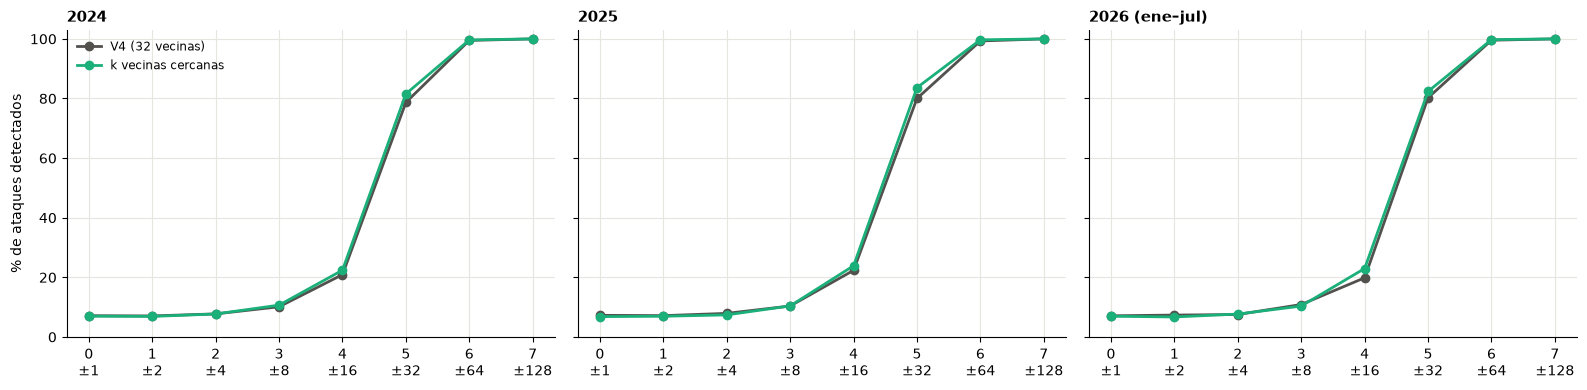

         fpr_micro_pct      precision_micro_pct       recall_micro_pct       
familia            knn   v4                 knn    v4              knn     v4
anio bit                                                                     
2024 0             6.7  7.0                 5.1   5.0              7.0    7.1
     1             6.7  7.0                 5.1   5.0              6.9    7.0
     2             6.7  7.0                 5.6   5.4              7.7    7.7
     3             6.7  7.0                 7.6   7.0             10.7   10.1
     4             6.7  7.0                14.8  13.4             22.4   20.9
     5             6.7  7.0                38.7  36.8             81.5   78.7
     6             6.7  7.0                43.6  42.4             99.7   99.5
     7             6.7  7.0                43.7  42.5            100.0  100.0
2025 0             7.1  7.2                 4.7   4.9              6.8    7.3
     1             7.1  7.2                 4.8   4.8           

In [7]:
if all(leer(f, 'metricas_pareadas_agregadas.csv') is not None for f in FAM):
    A = pd.concat([leer(f, 'metricas_pareadas_agregadas.csv').assign(familia=f) for f in FAM])
    A = A[A.grupo == 'principal']
    fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
    for ax, anio in zip(axes, [2024, 2025, 2026]):
        for fam in FAM:
            g = A[(A.familia == fam) & (A.anio == anio)]
            ax.plot(g.bit, g.recall_micro_pct, marker='o', color=COLOR[fam], label=ETIQ[fam])
        ax.set_title(f'{anio}' + (' (ene–jul)' if anio == 2026 else ''), loc='left')
        ax.set_xticks(range(8), [f'{b}\n±{2**b}' for b in range(8)]); ax.set_ylim(0, 103)
    axes[0].set_ylabel('% de ataques detectados'); axes[0].legend(fontsize=8.5)
    fig.tight_layout(); fig.savefig(IMG / 'recall_un_mensaje.png', dpi=150); plt.show()
    print(A.pivot_table(index=['anio', 'bit'], columns='familia',
                        values=['recall_micro_pct', 'precision_micro_pct', 'fpr_micro_pct']).round(1).to_string())
else:
    print('Falta la etapa «evaluar».')

## 6. Daño que se escapa y desactivaciones

In [8]:
if all(leer(f, 'resumen_dano_dias.csv') is not None for f in FAM):
    D = pd.concat([leer(f, 'resumen_dano_dias.csv').assign(familia=f) for f in FAM])
    print(D[D.tipo_dano.isin(['cambio_banda_red', 'falsa_fase1'])].pivot_table(
        index=['tipo_dano', 'anio', 'bit'], columns='familia', values='dias_dano_no_detectado').to_string())
    filas = []
    for fam in FAM:
        for anio in [2024, 2025, 2026]:
            f = FAM[fam] / f'eventos_dano/eventos_{anio}.parquet'
            if f.exists():
                ev = pd.read_parquet(f); an = ev[ev.anulada_fase1]
                exc = int(D[(D.familia == fam) & (D.anio == anio)].dias_con_excedencia_original.iat[0])
                filas.append(dict(familia=fam, anio=anio, dias_con_excedencia=exc, ocultables=an.fecha.nunique(),
                                  ocultables_sin_alerta=an[an.evaluable & ~an.detectado].fecha.nunique()))
    print('\nDesactivaciones (días):'); print(pd.DataFrame(filas).to_string(index=False))
else:
    print('Falta la etapa «evaluar».')

familia                     knn    v4
tipo_dano        anio bit            
cambio_banda_red 2024 0    10.0   8.0
                      1    17.0  14.0
                      2    17.0  17.0
                      3    65.0  66.0
                      4    83.0  70.0
                      5    92.0  85.0
                      6    25.0  26.0
                      7     0.0   0.0
                 2025 0    11.0   9.0
                      1    13.0  11.0
                      2    25.0  23.0
                      3    71.0  63.0
                      4    78.0  69.0
                      5    80.0  63.0
                      6    36.0  24.0
                      7     0.0   0.0
                 2026 0     2.0   2.0
                      1     2.0   2.0
                      2     8.0   7.0
                      3    32.0  27.0
                      4    36.0  34.0
                      5    35.0  32.0
                      6    14.0  15.0
                      7     0.0   0.0
falsa_fase1 

## 7. Atacante simultáneo

El V4 se toma de la ejecución de la variante contemporánea (mismo plan de horas, mismas
semillas).

In [9]:
fk = K / 'simultaneo/metricas_simultaneo_agregadas.csv'
if fk.exists() and SIM_V4.exists():
    S = pd.concat([pd.read_csv(SIM_V4).query("familia == 'v4'"), pd.read_csv(fk)])
    S = S[S.grupo == 'principal']
    print(S.pivot_table(index=['anio', 'bit'], columns='familia',
                        values=['recall_micro_pct', 'precision_micro_pct', 'fpr_micro_pct']).round(1).to_string())
else:
    print('Falta la etapa «simultaneo».')

         fpr_micro_pct       precision_micro_pct       recall_micro_pct       
familia            knn    v4                 knn    v4              knn     v4
anio bit                                                                      
2024 0             6.7   7.0                 4.8   4.8              6.4    6.7
     1             6.7   7.0                 4.8   4.9              6.4    6.8
     2             6.8   7.1                 5.4   5.3              7.3    7.4
     3             6.8   7.1                 7.2   6.6              9.9    9.4
     4             7.0   7.2                14.9  13.5             23.1   21.1
     5             8.3   8.4                33.2  32.1             77.3   74.2
     6            11.1  11.1                32.1  32.1             98.6   98.5
     7            19.2  18.3                21.7  22.6            100.0  100.0
2025 0             7.2   7.3                 4.0   4.3              6.2    6.7
     1             7.2   7.2                 4.2   4

## 8. Notas

#### 2026-10-05 — Primera ejecución completa

- **Qué se hizo:** `experiments/vecinas/ejecutar.py` lanzado por Claude el 2026-10-04 23:09;
  la laptop se apagó con 10/31 estaciones listas y FAC a medias (selección hecha, sin
  modelo final). Reanudado a las 23:34 sin borrar nada; FAC repitió su selección
  (determinista). Terminó el 2026-10-05 00:17 (43.3 min de la segunda corrida). CCA (k = 4)
  verificado reproducible. V4 cargado de disco.
- **Resultados:**
- **k elegido con 2022:** 4 en 21 estaciones, 8 en 7, 16 en 3, **32 en ninguna**. CCA:
  `val_loss` 131.6 con k = 4 frente a 154.0 con las 32.
- **Calibración 2023 (principales, mediana):** MAE V4 7.78 → knn 7.52 ppb (−3 %); umbral
  22.65 → 21.36 ppb; 27 de 30 estaciones bajan su MAE; error en lecturas ≥90 ppb 17.8 →
  16.0 ppb (sesgo +16.1 → +12.0). AJM: 12.51 → 9.73 ppb, ahora mejora al perfil (12.50).
  Empeoran GAM, NEZ y AJU (+0.3 a +0.6 ppb).
- **Limpio (FPR micro, principales):** 2024 7.02 → 6.71 %; 2025 7.22 → 7.12 %;
  2026 6.62 → 7.01 %. Baja representatividad sube (2024 7.39 → 8.52 %).
- **Un mensaje (principales):** bit 4 2024 20.9 → 22.4 %, 2025 22.3 → 23.9 %, 2026
  19.8 → 23.0 %; bit 5 78.7 → 81.5 %, 80.0 → 83.6 %, 80.2 → 82.4 %.
- **Daño (días con cambio de banda del máximo de red sin alerta):** 2024 bit 4 70 → 83,
  bit 5 85 → 92; 2025 bit 5 63 → 80; 2026 bit 5 32 → 35. Excedencia fabricada sin alerta,
  bit 5: 15 → 16 (2024), 7 → 9 (2025), 3 → 9 (2026). Desactivaciones sin alerta: 2/17,
  2/6 y 2/9 frente a 2/17, 2/6 y 0/9 del V4.
- **Detalle por evento (barrido, bit 5):** en 2024 knn deja pasar menos ataques dañinos
  (590 frente a 669) pero repartidos en más días (92 frente a 85); en 2025 más (1038
  frente a 933), sobre todo en PED (+51) y CCA (+34). El 99 % de los no detectados suben
  la lectura.
- **Atacante simultáneo (bit 5, principales):** knn 77.3 / 79.7 / 78.8 % frente a V4 74.2
  / 76.2 / 77.3 % (2024/25/26): no se vuelve frágil (sigue usando sólo el pasado).
- **Interpretación:** la idea del tesista mejora la predicción de forma consistente y sin
  fragilidad, pero no reduce el daño en decisiones que pasa sin alerta; en 2025 lo aumenta.
  Explicación propuesta (coherente con los datos, no medida causalmente): el V4
  subestimaba las lecturas altas y ese sesgo hacía más visibles los ataques que suben la
  lectura; al predecir mejor los picos, el mismo ataque parece menos anómalo. Predecir
  mejor no implica detectar mejor el ataque dañino.
- **Decisión:** se conserva el V4 como referencia; knn queda como variante documentada.


#### Plantilla

```
#### AAAA-MM-DD — título
- Qué se hizo:
- Resultados (k elegidos, calibración, limpio, un mensaje, daño, simultáneo):
- Interpretación:
- Decisiones / pendientes:
```